# Pseudotime trends of pathway & gene activity scores

Reproduces the pseudotime-trend animations from `rna_scoring_preproc.ipynb` in the human SKM multimodal repo, but driven entirely through `pygenelab`.

- Score DNA-damage / DNA-repair pathways with AUCell
- Smooth each score along pseudotime per `Annotation` group
- Animate a moving dot along the smoothed trace (MP4 if ffmpeg is on PATH, otherwise GIF)
- Same animator also drives a single-gene expression trace


In [13]:
%load_ext autoreload
%autoreload 2

import sys
import os
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

PYGENELAB_PARENT = Path("/ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/TA_muscle_code/py_scripts")
if str(PYGENELAB_PARENT) not in sys.path:
    sys.path.insert(0, str(PYGENELAB_PARENT))

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
ad.settings.allow_write_nullable_strings = True
import matplotlib.pyplot as plt

import pygenelab as pgl

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
import importlib
import pygenelab.geneset_activity
importlib.reload(pygenelab.geneset_activity)   # pull in the new functions
import pygenelab
importlib.reload(pygenelab)                    # re-run `from .geneset_activity import *`
import pygenelab as pgl

for fn in ("club_geneset_by_clean_label", "metab_directions_from_csv",
            "plot_score_grid_by_celltype"):
    assert hasattr(pgl, fn), f"missing {fn} — file: {pgl.geneset_activity.__file__}"
print("OK — loaded from:", pgl.geneset_activity.__file__)

OK — loaded from: /ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/TA_muscle_code/py_scripts/pygenelab/geneset_activity.py


In [15]:
# ---- paths / config (edit for your environment) ----
adata_path = "/ix/djishnu/Akanksha/datasets/SKM_multimodal_ageing/objects/rna_female_type2_ds_wrt_HALLMARK_DNA_REPAIR.h5ad"
geneset_dir = "/ix/djishnu/Akanksha/datasets/gene_sets/gene_sets"
figures_dir = Path("/ix/djishnu/Akanksha/datasets/ERCC1_KO/figures/skm_female_human")
figures_dir.mkdir(parents=True, exist_ok=True)

pseudotime_key = "Pseudotime"
group_by_key = "Annotation"
lognorm_layer = "lognorm"  # set to None to use adata.X for gene-level animation

## Load adata

In [16]:
rna_adata = sc.read_h5ad(adata_path)
print(rna_adata)
rna_adata.obs[group_by_key].value_counts()

AnnData object with n_obs × n_vars = 3989 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII', 'bead_count', 'age_categorical', 'GOBP_DNA_DAMAGE_RESPONSE', 'GOBP_DNA_REPAIR', 'HALLMARK_DNA_REPAIR', 'REACTOME_DNA_REPAIR'
    var: 'features', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'neighbors', 'pca', 'rank_genes_groups', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'score_aucell'
    varm: 'PCs'
    layers: 'counts', 'counts_float', 'lognorm'
    obsp: 'connectivities', 'distances'


Annotation
Type II        3391
ENOX1+ (II)     350
ID1+ (II)       241
DCLK1+ (II)       4
SAA2+ (II)        2
TNNT2+ (II)       1
Name: count, dtype: int64

## AUCell scoring of metabolism pathways (mouse → human orthologs)

Score the metabolic pathways enriched in the **mouse** Fast-IIx/IIb DEG analysis
(`3_geneset_scores/.../metabolism_enriched_pathways_F.csv`, decoupler
`source, target, direction` format with **mouse** gene symbols) on these
**human** Type II nuclei.

Because this adata is human, every mouse gene is bridged to its 1:1 human
ortholog (`human_mouse_1to1_orthologs.csv`) and the geneset is re-saved with
**both** the mouse and human symbol per gene. The human-space geneset is then
AUCell-scored with decoupler, and each pathway is plotted by chronological age
with the same violin + scatter + Cliff's-δ + Mann-Whitney-star API used above.
Outputs land in `6_human_skm_multimodal/Output/metabolic_scores/`.

In [17]:
# ── metabolism geneset: mouse → human ortholog mapping + AUCell scoring ──
from scipy import stats

metab_csv = (
    "/ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/TA_muscle_code/"
    "py_scripts/3_geneset_scores/msigdb metabolism enriched pathways mice/"
    "metabolism_enriched_pathways_F.csv"   # female enriched-metabolism geneset (mouse symbols)
)
ORTHOLOGS = "/ix/djishnu/Akanksha/datasets/gene_sets/gene_sets/human_mouse_1to1_orthologs.csv"

# output folder for this analysis section (mirrors the numbered-section layout)
metab_out_dir = Path(
    "/ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/TA_muscle_code/"
    "py_scripts/6_human_skm_multimodal/Output/metabolic_scores"
)
metab_out_dir.mkdir(parents=True, exist_ok=True)

# 1) mouse → human 1:1 ortholog map (CSV columns: human, mouse)
orth = pd.read_csv(ORTHOLOGS)
mouse_to_human = dict(zip(orth["mouse"], orth["human"]))

# 2) load the mouse geneset and attach the human ortholog for every gene
metab_mouse = pd.read_csv(metab_csv).rename(columns={"target": "mouse_gene"})
metab_mouse["human_gene"] = metab_mouse["mouse_gene"].map(mouse_to_human)

# 3) re-save the geneset carrying BOTH mouse + human symbols (and direction)
metab_mapped_csv = metab_out_dir / "metabolism_pathways_F_mouse_human.csv"
metab_mouse.to_csv(metab_mapped_csv, index=False)
print(f"wrote ortholog-mapped geneset -> {metab_mapped_csv}")

# 4) per-pathway mouse→human ortholog coverage
coverage = (
    metab_mouse.assign(mapped=metab_mouse["human_gene"].notna())
    .groupby("source")["mapped"].agg(n_mouse="size", n_human="sum")
)
coverage["frac_mapped"] = (coverage["n_human"] / coverage["n_mouse"]).round(3)
print("\nmouse → human ortholog coverage per pathway:")
print(coverage.to_string())

# 5) build the decoupler-format geneset in HUMAN gene space
#    (drop genes with no human ortholog, then dedupe)
metab_human_geneset = (
    metab_mouse.dropna(subset=["human_gene"])
    .loc[:, ["source", "human_gene"]]
    .rename(columns={"human_gene": "target"})
    .drop_duplicates()
    .reset_index(drop=True)
)
metabolism_pathways = sorted(metab_human_geneset["source"].unique())

# decoupler writes obsm['score_aucell'] with an object-dtype index; cast
# obs_names to plain object so it matches anndata's string[python] obs index
rna_adata.obs_names = np.asarray(rna_adata.obs_names, dtype=object)

# 6) AUCell-score every metabolic pathway into rna_adata.obs
pgl.report_geneset_overlap(metab_human_geneset, rna_adata)
scored_metab = pgl.score_geneset_aucell(
    rna_adata,
    metab_human_geneset,
    raw=False,
    verbose=True,
    copy_to_obs=True,
)
print("\nScored metabolic pathways:", scored_metab)

2026-06-06 15:32:06 | [INFO] aucell - Running aucell
2026-06-06 15:32:06 | [INFO] Extracted omics mat with 3989 rows (observations) and 48355 columns (features)
2026-06-06 15:32:06 | [WARNING] 13973 features of mat are empty, they will be removed
2026-06-06 15:32:06 | [WARNING] weight not found in net.columns, adding it as:
net['weight'] = 1
2026-06-06 15:32:06 | [INFO] Network has 799 unique features and 8 unique sources


wrote ortholog-mapped geneset -> /ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/TA_muscle_code/py_scripts/6_human_skm_multimodal/Output/metabolic_scores/metabolism_pathways_F_mouse_human.csv

mouse → human ortholog coverage per pathway:
                                       n_mouse  n_human  frac_mapped
source                                                              
HALLMARK_FATTY_ACID_METABOLISM             155      131        0.845
HALLMARK_XENOBIOTIC_METABOLISM             196      173        0.883
REACTOME_GLYCOGEN_METABOLISM                18       15        0.833
REACTOME_GLYCOSAMINOGLYCAN_METABOLISM      122      116        0.951
REACTOME_METABOLISM_OF_CARBOHYDRATES       261      231        0.885
REACTOME_PHOSPHOLIPID_METABOLISM           192      168        0.875
REACTOME_PYRUVATE_METABOLISM                45       36        0.800
WP_PURINE_METABOLISM                       172      143        0.831
[geneset] 823/826 genes present in adata.var_names (3 missin

2026-06-06 15:32:06 | [INFO] aucell - calculating 8 AUCs for 34382 targets across 3989 observations, categorizing features at rank=1720


  0%|          | 0/3989 [00:00<?, ?it/s]

2026-06-06 15:32:15 | [INFO] aucell - done



Scored metabolic pathways: ['HALLMARK_FATTY_ACID_METABOLISM', 'HALLMARK_XENOBIOTIC_METABOLISM', 'REACTOME_GLYCOGEN_METABOLISM', 'REACTOME_GLYCOSAMINOGLYCAN_METABOLISM', 'REACTOME_METABOLISM_OF_CARBOHYDRATES', 'REACTOME_PHOSPHOLIPID_METABOLISM', 'REACTOME_PYRUVATE_METABOLISM', 'WP_PURINE_METABOLISM']


In [12]:
# ── violin + box of every metabolic score across chronological age ──
# Same plotting API as the DNA-damage / Z12 cells: violin + per-cell scatter,
# Cliff's-δ annotation, and Mann-Whitney significance stars. One SVG + PNG per
# pathway is saved under Output/metabolic_scores/, plus a summary CSV.
#
# significance-star thresholds (two-sided Mann-Whitney U, age 34 vs 80):
#     *  p < 0.05     **  p < 0.01     ***  p < 0.001
ADATA_NAME = "rna_female_type2"
GROUP_COL  = "age_yrs"

# age is int in obs; make a string copy so it can act as a categorical group
rna_adata.obs[GROUP_COL] = rna_adata.obs["age"].astype(int).astype(str)
GROUPS  = sorted(rna_adata.obs[GROUP_COL].unique(), key=int)   # ['34', '80']
PALETTE = {"34": "#7B1FA2", "80": "#3D1F5C"}

print("significance-star thresholds (Mann-Whitney U, age "
      f"{GROUPS[0]} vs {GROUPS[-1]}):  *  p<0.05   **  p<0.01   ***  p<0.001\n")

summary_rows = []
for SCORE_COL in metabolism_pathways:
    # Cliff's δ youngest vs oldest
    cliffs_df, _ = pgl.calculate_score_cliffs_delta(
        adata=rna_adata, score_col=SCORE_COL, group_col=GROUP_COL,
        group1=GROUPS[0], group2=GROUPS[-1],
    )
    cliffs_row = cliffs_df.iloc[0]
    delta  = float(cliffs_row["abs_cliffs_delta"])
    higher = cliffs_row["higher_group"]

    # Mann-Whitney p-value + star symbol (the threshold behind the asterisks)
    s_young = rna_adata.obs.loc[rna_adata.obs[GROUP_COL] == GROUPS[0],  SCORE_COL].dropna()
    s_old   = rna_adata.obs.loc[rna_adata.obs[GROUP_COL] == GROUPS[-1], SCORE_COL].dropna()
    _, pval = stats.mannwhitneyu(s_young, s_old, alternative="two-sided")
    stars = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"

    DELTA_LABEL = f"Cliff's δ = {delta:.3f} (higher in {higher})"
    _, violin_fig = pgl.plot_score_by_group(
        adata=rna_adata, score_col=SCORE_COL, group_col=GROUP_COL,
        palette=PALETTE, group_order=list(GROUPS),
        title=f"Female Type II: {SCORE_COL}",
        show_scatter=False, scatter_alpha=0.5, scatter_size=2,
        show_pvalue=False,            # asterisks only on the plot
        delta_label=DELTA_LABEL, group_spacing=0.8, ylim=None,
    )
    stem = f"{ADATA_NAME}_{SCORE_COL}_by_age_violin"
    violin_fig.savefig(metab_out_dir / f"{stem}.svg", bbox_inches="tight")
    violin_fig.savefig(metab_out_dir / f"{stem}.png", dpi=300, bbox_inches="tight")
    plt.close(violin_fig)

    summary_rows.append({
        "pathway": SCORE_COL, "cliffs_delta": round(delta, 3),
        "higher_in_age": higher, "mannwhitney_p": pval, "stars": stars,
    })
    print(f"{SCORE_COL:40s} δ={delta:.3f}  higher@{higher:>2}  p={pval:.2e}  {stars}")

metab_summary = (
    pd.DataFrame(summary_rows)
    .sort_values("cliffs_delta", ascending=False)
    .reset_index(drop=True)
)
metab_summary.to_csv(
    metab_out_dir / f"{ADATA_NAME}_metabolism_cliffs_significance.csv", index=False
)
print(f"\nsaved {len(metabolism_pathways)} violin plots + summary -> {metab_out_dir}")
metab_summary

2026-06-06 15:14:19 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-06 15:14:19 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-06 15:14:19 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


significance-star thresholds (Mann-Whitney U, age 34 vs 80):  *  p<0.05   **  p<0.01   ***  p<0.001



2026-06-06 15:14:19 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-06 15:14:19 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-06 15:14:19 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-06 15:14:20 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-06 15:14:20 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

HALLMARK_FATTY_ACID_METABOLISM           δ=0.105  higher@80  p=1.05e-08  ***


2026-06-06 15:14:20 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-06 15:14:20 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-06 15:14:20 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-06 15:14:20 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-06 15:14:20 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

...

REACTOME_PHOSPHOLIPID_METABOLISM         δ=0.399  higher@80  p=1.54e-105  ***


2026-06-06 15:14:22 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-06 15:14:23 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-06 15:14:23 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-06 15:14:23 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-06 15:14:23 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

REACTOME_PYRUVATE_METABOLISM             δ=0.244  higher@80  p=1.51e-40  ***
WP_PURINE_METABOLISM                     δ=0.218  higher@34  p=9.90e-33  ***

saved 8 violin plots + summary -> /ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/TA_muscle_code/py_scripts/6_human_skm_multimodal/Output/metabolic_scores


,pathway,cliffs_delta,higher_in_age,mannwhitney_p,stars
0,REACTOME_METABOLISM_OF_CARBOHYDRATES,0.642,34,8.682634e-270,***
1,REACTOME_GLYCOGEN_METABOLISM,0.526,34,3.999151e-182,***
2,REACTOME_PHOSPHOLIPID_METABOLISM,0.399,80,1.542753e-105,***
3,HALLMARK_XENOBIOTIC_METABOLISM,0.356,80,1.241171e-84,***
4,REACTOME_PYRUVATE_METABOLISM,0.244,80,1.513245e-40,***
5,WP_PURINE_METABOLISM,0.218,34,9.901236e-33,***
6,REACTOME_GLYCOSAMINOGLYCAN_METABOLISM,0.203,34,9.734317e-29,***
7,HALLMARK_FATTY_ACID_METABOLISM,0.105,80,1.046215e-08,***


<Figure size 640x480 with 0 Axes>

## DNA Damage pathways

In [ ]:
dna_damage_pathways = [
    "GOBP_DNA_REPAIR",
    "GOBP_DNA_DAMAGE_RESPONSE",
    "REACTOME_DNA_REPAIR",
    "HALLMARK_DNA_REPAIR",
]

geneset_gmts = [
    os.path.join(geneset_dir, "human/DNA_repair/GOBP_DNA_REPAIR.v2024.1.Hs.gmt"),
    os.path.join(geneset_dir, "human/DNA_damage_response/GOBP_DNA_DAMAGE_RESPONSE.v2024.1.Hs.gmt"),
    os.path.join(geneset_dir, "human/DNA_repair/REACTOME_DNA_REPAIR.v2024.1.Hs.gmt"),
    os.path.join(geneset_dir, "human/DNA_repair/HALLMARK_DNA_REPAIR.v2024.1.Hs.gmt"),
]

missing_pathway_cols = [c for c in dna_damage_pathways if c not in rna_adata.obs.columns]
if missing_pathway_cols:
    print(f"Scoring {len(missing_pathway_cols)} missing pathways with AUCell...")
    geneset_df = pgl.geneset_from_gmts(geneset_gmts, gene_origin="human")
    pgl.report_geneset_overlap(geneset_df, rna_adata)
    pathways = pgl.score_geneset_aucell(
        rna_adata,
        geneset_df,
        raw=False,
        verbose=True,
        copy_to_obs=True,
    )
    print("Scored pathways:", pathways)
else:
    print("All DNA-damage pathway scores already present in adata.obs - skipping AUCell")

## Build cell-level scores DataFrame

In [11]:
obs_cols_keep = ["sample", "age", pseudotime_key, group_by_key]
obs_cols_keep = [c for c in obs_cols_keep if c in rna_adata.obs.columns]

cell_level_scores_df = rna_adata.obs[obs_cols_keep + dna_damage_pathways].copy()
cell_level_scores_df.head()

NameError: name 'dna_damage_pathways' is not defined

## Score trend wrt chronological age

In [38]:
# Use cell-level data directly from adata.obs
cell_level_scores_df = rna_adata.obs[['sample', 'age', 'Annotation', 'Pseudotime'] + dna_damage_pathways].copy()
# geneset_sizes_data = {
#     'KEGG_OXIDATIVE_PHOSPHORYLATION': 132,
#     'GOBP_FATTY_ACID_BETA_OXIDATION': 75,
#     'KEGG_GLYCOLYSIS_GLUCONEOGENESIS': 62,
#     'KEGG_CITRATE_CYCLE_TCA_CYCLE': 31,
#     'REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM': 21,
#     'REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM': 14
# }
geneset_sizes_data = {
    'GOBP_DNA_REPAIR': 615,
    'GOBP_DNA_DAMAGE_RESPONSE': 906,
    'REACTOME_DNA_REPAIR': 332,
    'HALLMARK_DNA_REPAIR': 150
}
geneset_sizes_series = pd.Series(geneset_sizes_data)

2026-06-02 00:49:43 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-02 00:49:43 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-02 00:49:43 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-02 00:49:43 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-02 00:49:43 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-02 00:49:43 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-02 00:49:43 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-02 00:49:43 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

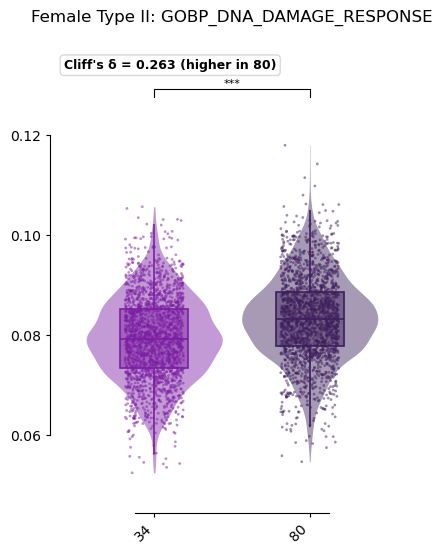

<Figure size 640x480 with 0 Axes>

In [39]:
# --- DNA-damage-response score across chronological age (Female Type II) ---
ADATA_NAME = "rna_female_type2"
SCORE_COL  = "GOBP_DNA_DAMAGE_RESPONSE"   # DNA-damage-response decoupler/AUCell score
GROUP_COL  = "age_yrs"                     # chronological age as a categorical x-axis
OUTPUT_DIR = figures_dir

# age is int in obs; make a string copy so it can act as a categorical group
# (keeps the original numeric `age` intact for the regression cell below)
rna_adata.obs[GROUP_COL] = rna_adata.obs["age"].astype(int).astype(str)

# age groups present, youngest -> oldest
GROUPS = sorted(rna_adata.obs[GROUP_COL].unique(), key=int)   # ['34', '80']

PALETTE = {
    "34": "#7B1FA2",
    "80": "#3D1F5C",
}

# Cliff's delta between youngest and oldest age, in the original snippet's style
cliffs_df, _ = pgl.calculate_score_cliffs_delta(
    adata=rna_adata,
    score_col=SCORE_COL,
    group_col=GROUP_COL,
    group1=GROUPS[0],
    group2=GROUPS[-1],
)
cliffs_row = cliffs_df.iloc[0]
DELTA_LABEL = (
    f"Cliff's δ = {float(cliffs_row['abs_cliffs_delta']):.3f} "
    f"(higher in {cliffs_row['higher_group']})"
)

plot_df, violin_fig = pgl.plot_score_by_group(
    adata=rna_adata,
    score_col=SCORE_COL,
    group_col=GROUP_COL,
    palette=PALETTE,
    group_order=list(GROUPS),
    title=f"Female Type II: {SCORE_COL}",
    show_scatter=True,   # set True to overlay per-cell dots on the violins
    scatter_alpha=0.5,
    scatter_size=2,
    show_pvalue=False,    # asterisks only, no numeric p-value
    delta_label=DELTA_LABEL,
    group_spacing=0.8,
    ylim=None,
)
violin_fig.savefig(OUTPUT_DIR / f"{ADATA_NAME}_{SCORE_COL}_by_age_violin.svg", bbox_inches="tight")
violin_fig

## Transferred SLIDE Z12 score across chronological age

Project these human Type II nuclei onto **Z12** of the mouse SLIDE model
(female fast-2b/2x ERCC1-KO metacells) via `pgl.crossprediction` — reusing the
mouse A-loadings, no retraining and no AUCell — then show the per-cell score by
age with the same violin + scatter + Cliff's-delta style used above.

In [ ]:
# --- compute the transferred Z12 score onto the human cells ----------------
# pgl.crossprediction loads the mouse SLIDE model (rpy2 + base-R readRDS),
# bridges mouse->human 1:1 orthologs, runs EssReg predZ, and writes
# rna_adata.obs["Z12_transfer_score"], sign-oriented so higher = older.
MODEL_DIR = "/ix/djishnu/Akanksha/datasets/ERCC1_KO/metacell/slide_outs/optimize_slide/female_0.1_spec/0.01_1_out"
ORTHOLOGS = "/ix/djishnu/Akanksha/datasets/gene_sets/gene_sets/human_mouse_1to1_orthologs.csv"

is_old = (rna_adata.obs["age"].astype(int) == rna_adata.obs["age"].astype(int).max()).values
pgl.crossprediction.transfer_latent_scores(
    rna_adata, MODEL_DIR, ORTHOLOGS,
    lfs=["Z12"], orient_by=is_old, verbose=True)
rna_adata.obs[["age", "Z12_transfer_score"]].head()

In [ ]:
# --- Transferred Z12 score across chronological age (Female Type II) ---
ADATA_NAME = "rna_female_type2"
SCORE_COL  = "Z12_transfer_score"   # mouse SLIDE Z12, projected onto human cells
GROUP_COL  = "age_yrs"              # chronological age as a categorical x-axis
OUTPUT_DIR = figures_dir

# age is int in obs; make a string copy so it can act as a categorical group
rna_adata.obs[GROUP_COL] = rna_adata.obs["age"].astype(int).astype(str)

# age groups present, youngest -> oldest
GROUPS = sorted(rna_adata.obs[GROUP_COL].unique(), key=int)   # ['34', '80']

PALETTE = {
    "34": "#7B1FA2",
    "80": "#3D1F5C",
}

# Cliff's delta between youngest and oldest age
cliffs_df, _ = pgl.calculate_score_cliffs_delta(
    adata=rna_adata,
    score_col=SCORE_COL,
    group_col=GROUP_COL,
    group1=GROUPS[0],
    group2=GROUPS[-1],
)
cliffs_row = cliffs_df.iloc[0]
DELTA_LABEL = (
    f"Cliff's δ = {float(cliffs_row['abs_cliffs_delta']):.3f} "
    f"(higher in {cliffs_row['higher_group']})"
)

plot_df, violin_fig = pgl.plot_score_by_group(
    adata=rna_adata,
    score_col=SCORE_COL,
    group_col=GROUP_COL,
    palette=PALETTE,
    group_order=list(GROUPS),
    title=f"Female Type II: transferred {SCORE_COL}",
    show_scatter=True,    # overlay per-cell dots on the violins
    scatter_alpha=0.5,
    scatter_size=2,
    show_pvalue=False,    # asterisks only, no numeric p-value
    delta_label=DELTA_LABEL,
    group_spacing=0.8,
    ylim=None,
)
violin_fig.savefig(OUTPUT_DIR / f"{ADATA_NAME}_{SCORE_COL}_by_age_violin.svg", bbox_inches="tight")
violin_fig

In [ ]:
# ── driver-gene heatmap for the transferred Z12 score (human) ──
# A biologist-facing view of Z12's drivers (instead of a within-age correlation,
# which can flip sign even when a gene is clearly up in old):
#   heatmap = each driver's mean z-scored expression in young vs old human cells
#             (red = above-average for that age, e.g. PDK4 up in old)
# Genes are ordered by SLIDE A_loading (driver strength). Pass
# show_loading_bar=True to add the A_loading side bar.
drv_tab, drv_fig = pgl.crossprediction.plot_transferred_driver_heatmap(
    rna_adata, MODEL_DIR, "Z12", ORTHOLOGS,
    group_col=GROUP_COL, groups=list(GROUPS), group_labels=["young (34)", "old (80)"],
    top_n=20,
    title="Z12 drivers — Female Type II human (young vs old)",
)
drv_stem = f"{ADATA_NAME}_Z12_transfer_drivers_heatmap"
drv_fig.savefig(OUTPUT_DIR / f"{drv_stem}.svg", bbox_inches="tight")
drv_fig.savefig(OUTPUT_DIR / f"{drv_stem}.png", dpi=300, bbox_inches="tight")
print(f"saved -> {OUTPUT_DIR / (drv_stem + '.png')}")
drv_tab.round(2)

age_yrs    n     mean      sem      std      err
     34 1989 0.423831 0.018424 0.821676 0.036111
     80 2000 1.085810 0.023498 1.050879 0.046057


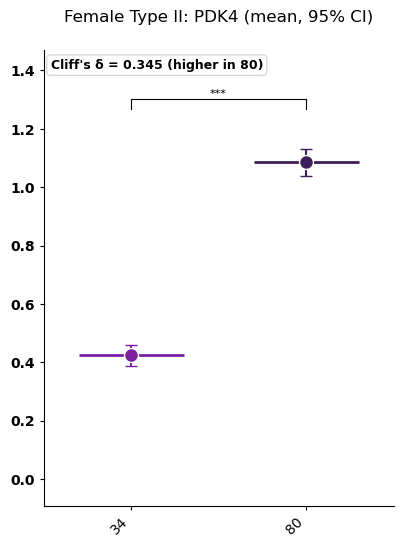

<Figure size 640x480 with 0 Axes>

In [40]:
# --- PDK4 mean-expression trend across chronological age ---
# PDK4 is silent in most young Type II nuclei (~78% lognorm == 0 at age 34),
# so a box/violin collapses to a flat line at 0. A mean (dot + bar) with a
# 95% CI per age is a clearer representation for such a sparse gene.
# (SD is huge / dips below 0; SEM is tiny — 95% CI = 1.96*SEM is the standard
# error bar on a mean and cleanly separates the two ages.)
GENE = "PDK4"

pdk4_summary, pdk4_fig = pgl.plot_gene_mean_trend_by_group(
    rna_adata,
    gene=GENE,
    group_col=GROUP_COL,          # "age_yrs" (string age) from the DDR cell above
    layer=lognorm_layer,          # "lognorm"
    palette=PALETTE,
    group_order=list(GROUPS),     # ['34', '80']
    error="ci95",                 # error bar half-width: "sem" | "std" | "ci95"
    title=f"Female Type II: {GENE} (mean, 95% CI)",
    show_pvalue=False,            # asterisks only (*, **, ***)
)
print(pdk4_summary.to_string(index=False))
pdk4_fig.savefig(OUTPUT_DIR / f"{ADATA_NAME}_{GENE}_by_age_meantrend.svg", bbox_inches="tight")
pdk4_fig

## Pseudotime correlation with chronological age

In [ ]:
from scipy import stats

# per-cell pseudotime and chronological age
pt_age_df = rna_adata.obs[[pseudotime_key, "age"]].copy()
pt_age_df["age"] = pt_age_df["age"].astype(float)
pt_age_df[pseudotime_key] = pt_age_df[pseudotime_key].astype(float)
pt_age_df = pt_age_df.dropna(subset=[pseudotime_key, "age"])

age = pt_age_df["age"].values
pt = pt_age_df[pseudotime_key].values

# linear regression: pseudotime ~ age
slope, intercept, r_value, p_value, std_err = stats.linregress(age, pt)
r_squared = r_value**2
print(f"Pearson r = {r_value:.3f} | R^2 = {r_squared:.3f} | p = {p_value:.2e} | n = {len(pt)} cells")

# per-age-group mean +/- sd of pseudotime
group_stats = pt_age_df.groupby("age")[pseudotime_key].agg(["mean", "std", "count"])
print(group_stats)

fig, ax = plt.subplots(figsize=(6, 5))

# jitter ages a bit so the three discrete columns of points are visible
rng = np.random.default_rng(0)
jitter = rng.normal(0, 0.8, size=len(age))
ax.scatter(age + jitter, pt, s=8, alpha=0.25, color="#191970", edgecolors="none",
           label="cells")

# regression line over the observed age range
x_line = np.linspace(age.min(), age.max(), 100)
ax.plot(x_line, intercept + slope * x_line, color="crimson", lw=2,
        label="linear fit")

# group means
ax.scatter(group_stats.index, group_stats["mean"], s=120, color="black",
           marker="D", zorder=5, label="age-group mean")

ax.set_xlabel("Chronological age (years)")
ax.set_ylabel("Pseudotime (0-100)")
ax.set_xticks(sorted(pt_age_df["age"].unique()))
ax.set_ylim(0, 100)
ax.set_title("Pseudotime vs chronological age")
ax.text(0.05, 0.95, f"$R^2$ = {r_squared:.3f}\np = {p_value:.2e}",
        transform=ax.transAxes, va="top", ha="left",
        bbox=dict(boxstyle="round", fc="white", ec="0.7", alpha=0.9))
ax.legend(loc="lower right", frameon=False)
fig.tight_layout()
fig.savefig(figures_dir / "pseudotime_vs_age_r2.png", dpi=300, bbox_inches="tight")
plt.show()

## Animation: pathway score vs pseudotime

In [ ]:
plot_colors = {"Type II": "#191970"}
legend_labels = {"Type II": "Type II"}

score_cols_to_plot = ["GOBP_DNA_DAMAGE_RESPONSE"]

anim_result = pgl.create_animated_pathway_plot(
    df_cell_level=cell_level_scores_df,
    score_cols=score_cols_to_plot,
    pseudotime_key=pseudotime_key,
    group_by_key=group_by_key,
    smoothing_method="gaussian",
    smoothing_strength=120.0,
    geneset_sizes=geneset_sizes_series,
    groups_to_plot=["Type II"],
    colors_dict=plot_colors,
    legend_labels_map=legend_labels,
    n_subplot_cols=1,
    figsize_per_subplot=(7, 4),
    nframes=200,
    fps=30,
    dot_size=150,
    output_file=str(figures_dir / "pathway_animation.mp4"),
    use_gif=None,  # autodetect ffmpeg, fall back to GIF
)
print("Animation creation complete")

In [ ]:
# all four DNA-damage / DNA-repair pathways in a 2x2 grid
anim_result_multi = pgl.create_animated_pathway_plot(
    df_cell_level=cell_level_scores_df,
    score_cols=dna_damage_pathways,
    pseudotime_key=pseudotime_key,
    group_by_key=group_by_key,
    smoothing_method="gaussian",
    smoothing_strength=120.0,
    geneset_sizes=geneset_sizes_series,
    groups_to_plot=["Type II"],
    colors_dict=plot_colors,
    legend_labels_map=legend_labels,
    n_subplot_cols=2,
    figsize_per_subplot=(7, 4),
    nframes=200,
    fps=30,
    dot_size=150,
    output_file=str(figures_dir / "dna_damage_pathways_animation.mp4"),
    use_gif=None,
)

## Animation: single-gene expression vs pseudotime

In [ ]:
gene_of_interest = "PDK4"

anim_gene = pgl.animate_gene_along_pseudotime(
    rna_adata,
    genes=gene_of_interest,
    pseudotime_key=pseudotime_key,
    group_by_key=group_by_key,
    layer=lognorm_layer,
    smoothing_strength=120.0,
    groups_to_plot=["Type II"],
    colors_dict=plot_colors,
    legend_labels_map=legend_labels,
    output_file=str(figures_dir / f"{gene_of_interest.lower()}_animation.mp4"),
    use_gif=None,
)

In [ ]:
# multiple genes in one grid
goi_list = ["PDK4", "IRS2", "NR4A3", "FABP4"]
goi_list = [g for g in goi_list if g in rna_adata.var_names]

anim_gene_multi = pgl.animate_gene_along_pseudotime(
    rna_adata,
    genes=goi_list,
    pseudotime_key=pseudotime_key,
    group_by_key=group_by_key,
    layer=lognorm_layer,
    smoothing_strength=120.0,
    groups_to_plot=["Type II"],
    colors_dict=plot_colors,
    legend_labels_map=legend_labels,
    n_subplot_cols=2,
    output_file=str(figures_dir / "goi_animation.mp4"),
    use_gif=None,
)